**Task IX.A**: Train a Masked Autoencoder (MAE) on the no_sub samples from the provided dataset to learn a feature representation of strong lensing images. The MAE should be trained for reconstructing masked portions of input images. Once this pre-training phase is complete, fine-tune the model on the full dataset for a multi-class classification task to distinguish between the three classes. Please implement your approach in PyTorch or Keras and discuss your strategy.    
**Dataset**: https://drive.google.com/file/d/1znqUeFzYz-DeAE3dYXD17qoMPK82Whji/view?usp=sharing    
**Dataset Description**: The Dataset consists of three classes: no_sub (no substructure), cdm (cold dark matter substructure), and axion (axion-like particle substructure).   
**Evaluation Metrics**: ROC curve (Receiver Operating Characteristic curve) and AUC score (Area Under the ROC Curve) 


In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import random
from torch.utils.data import Dataset, DataLoader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LensDataset(Dataset):
    def __init__(self, root, classes, augment=False):
        self.files = []
        self.labels = []
        self.augment = augment

        for i, cls in enumerate(classes):
            cls_dir = os.path.join(root, cls)
            for f in os.listdir(cls_dir):
                if f.endswith(".npy") and not f.startswith("."):
                    self.files.append(os.path.join(cls_dir, f))
                    self.labels.append(i)

    def __len__(self):
        return len(self.files)

    def _unwrap(self, arr):
        while isinstance(arr, np.ndarray) and arr.dtype == object:
            arr = arr[0]
        if isinstance(arr, dict):
            arr = list(arr.values())[0]
        if isinstance(arr, list):
            arr = arr[0]
        return arr

    def _augment(self, img):
        if random.random() > 0.5:
            img = TF.hflip(img)
        if random.random() > 0.5:
            img = TF.vflip(img)
        angle = random.choice([0, 90, 180, 270])
        img = TF.rotate(img, angle)
        return img

    def __getitem__(self, idx):
        img = np.load(self.files[idx], allow_pickle=True)
        img = self._unwrap(img)
        img = np.asarray(img, dtype=np.float32).reshape(64, 64)

        img_min, img_max = img.min(), img.max()
        if img_max - img_min > 0:
            img = (img - img_min) / (img_max - img_min)

        img = torch.from_numpy(img).unsqueeze(0)  # (1, 64, 64)

        if self.augment:
            img = self._augment(img)

        return img, self.labels[idx]

In [3]:
import torch
import torch.nn as nn


class PatchEmbed(nn.Module):

    def __init__(self, img_size=64, patch_size=4, embed_dim=192):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(
            1, embed_dim, kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)       # B, C, H/p, W/p
        x = x.flatten(2)       # B, C, N
        x = x.transpose(1, 2)  # B, N, C
        return x

In [4]:
class TransformerBlock(nn.Module):

    def __init__(self, dim, heads=3):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, x):
        h = x
        x = self.norm1(x)
        x, _ = self.attn(x, x, x)
        x = x + h

        h = x
        x = self.norm2(x)
        x = self.mlp(x)
        x = x + h
        return x

In [ ]:
class ViTEncoder(nn.Module):
    NUM_PATCHES = 256  # (64 // 4)^2

    def __init__(self, embed_dim=192, depth=6, heads=3):
        super().__init__()
        self.embed_dim   = embed_dim
        self.patch_embed = PatchEmbed(embed_dim=embed_dim)
        self.pos_embed   = nn.Parameter(torch.randn(1, self.NUM_PATCHES, embed_dim))
        self.blocks      = nn.ModuleList([
            TransformerBlock(embed_dim, heads) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.patch_embed(x)  # (B, 256, C)
        x = x + self.pos_embed
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)

In [ ]:
def random_masking(x, mask_ratio):
    B, N, D = x.shape
    len_keep = int(N * (1 - mask_ratio))

    noise        = torch.rand(B, N, device=x.device)
    ids_shuffle  = torch.argsort(noise, dim=1)
    ids_restore  = torch.argsort(ids_shuffle, dim=1)
    ids_keep     = ids_shuffle[:, :len_keep]

    x_masked = torch.gather(
        x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D)
    )

    mask = torch.ones(B, N, device=x.device)
    mask[:, :len_keep] = 0
    mask = torch.gather(mask, 1, ids_restore)

    return x_masked, mask, ids_restore

In [ ]:
class MAE(nn.Module):
    def __init__(self, mask_ratio=0.75, embed_dim=192, decoder_depth=4):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.encoder    = ViTEncoder(embed_dim=embed_dim)

        self.mask_token       = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.decoder_pos_embed = nn.Parameter(
            torch.randn(1, ViTEncoder.NUM_PATCHES, embed_dim)
        )
        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, 3) for _ in range(decoder_depth)
        ])
        self.decoder_norm = nn.LayerNorm(embed_dim)
        self.decoder_pred = nn.Linear(embed_dim, 4 * 4)  # 16 pixels per patch

    def patchify(self, imgs):
        """(B,1,H,W) → (B, N, p²)"""
        p = 4
        B, C, H, W = imgs.shape
        x = imgs.reshape(B, C, H // p, p, W // p, p)
        x = x.permute(0, 2, 4, 3, 5, 1).reshape(B, 256, p * p)
        return x

    def forward(self, imgs):
        x = self.encoder.patch_embed(imgs) + self.encoder.pos_embed

        x_masked, mask, ids_restore = random_masking(x, self.mask_ratio)

        latent = x_masked
        for blk in self.encoder.blocks:
            latent = blk(latent)
        latent = self.encoder.norm(latent)

        B, N, D = latent.shape
        mask_tokens = self.mask_token.repeat(B, ids_restore.shape[1] - N, 1)
        x_ = torch.cat([latent, mask_tokens], dim=1)
        x_ = torch.gather(
            x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, D)
        )
        x_ = x_ + self.decoder_pos_embed
        for blk in self.decoder_blocks:
            x_ = blk(x_)
        x_ = self.decoder_norm(x_)
        pred = self.decoder_pred(x_)  # (B, 256, 16)

        target = self.patchify(imgs)
        mean   = target.mean(dim=-1, keepdim=True)
        var    = target.var(dim=-1, keepdim=True)
        target = (target - mean) / (var + 1e-6).sqrt()

        loss = ((pred - target) ** 2).mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()
        return loss

In [ ]:
import math
from torch.optim import AdamW
from tqdm import tqdm


def train_mae(model, loader, device, epochs=30, lr=1.5e-4, warmup_epochs=5):
    model.to(device)
    optimizer    = AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    total_steps  = epochs * len(loader)
    warmup_steps = warmup_epochs * len(loader)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for imgs, _ in tqdm(loader, desc=f"MAE Epoch {epoch+1}/{epochs}"):
            imgs = imgs.to(device)
            loss = model(imgs)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()
        print(
            f"Epoch {epoch+1:>2}  loss {total_loss/len(loader):.6f}  "
            f"lr {optimizer.param_groups[0]['lr']:.2e}"
        )

In [ ]:
device = "cuda"
from torch.utils.data import random_split

data_root = "/kaggle/input/datasets/anukultiwari/foundation-model/Dataset"

no_sub_dataset = LensDataset(data_root, ["no_sub"], augment=False)
mae_loader     = DataLoader(no_sub_dataset, batch_size=64, shuffle=True)

classes   = ["no_sub", "cdm", "axion"]
train_ds  = LensDataset(data_root, classes, augment=True)   # augmented train split
test_ds   = LensDataset(data_root, classes, augment=False)  # clean test split

n_total   = len(LensDataset(data_root, classes))
n_train   = int(0.9 * n_total)
n_test    = n_total - n_train
indices   = torch.randperm(n_total, generator=torch.Generator().manual_seed(42)).tolist()
train_indices, test_indices = indices[:n_train], indices[n_train:]

from torch.utils.data import Subset
train_split = Subset(LensDataset(data_root, classes, augment=True),  train_indices)
test_split  = Subset(LensDataset(data_root, classes, augment=False), test_indices)

mae = MAE(mask_ratio=0.90)
train_mae(mae, mae_loader, device, epochs=15, lr=1.5e-4, warmup_epochs=3)

MAE Epoch 1/15: 100%|██████████| 461/461 [06:19<00:00,  1.21it/s]


Epoch  1  loss 0.263600  lr 5.00e-05


MAE Epoch 2/15: 100%|██████████| 461/461 [00:51<00:00,  8.87it/s]


Epoch  2  loss 0.089650  lr 1.00e-04


MAE Epoch 3/15: 100%|██████████| 461/461 [00:46<00:00,  9.96it/s]


...

Epoch 13  loss 0.002541  lr 1.00e-05


MAE Epoch 14/15: 100%|██████████| 461/461 [00:46<00:00, 10.01it/s]


Epoch 14  loss 0.002457  lr 2.56e-06


MAE Epoch 15/15: 100%|██████████| 461/461 [00:45<00:00, 10.21it/s]

Epoch 15  loss 0.002287  lr 0.00e+00


In [ ]:
import torch
import matplotlib.pyplot as plt


def unpatchify(x, patch_size=4, img_size=64):
    p = patch_size
    h = w = img_size // p
    B = x.shape[0]
    x = x.reshape(B, h, w, p, p, 1)
    x = x.permute(0, 5, 1, 3, 2, 4).reshape(B, 1, h * p, w * p)
    return x


def show_mae_reconstruction(model, dataloader, device, n=5):
    model.eval()
    imgs, _ = next(iter(dataloader))
    imgs = imgs[:n].to(device)

    with torch.no_grad():
        x = model.encoder.patch_embed(imgs) + model.encoder.pos_embed
        x_masked, mask, ids_restore = random_masking(x, model.mask_ratio)

        latent = x_masked
        for blk in model.encoder.blocks:
            latent = blk(latent)
        latent = model.encoder.norm(latent)

        B, N, D = latent.shape
        mask_tokens = model.mask_token.repeat(B, ids_restore.shape[1] - N, 1)
        x_ = torch.cat([latent, mask_tokens], dim=1)
        x_ = torch.gather(
            x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, D)
        )
        x_ = x_ + model.decoder_pos_embed
        for blk in model.decoder_blocks:
            x_ = blk(x_)
        x_ = model.decoder_norm(x_)
        pred = model.decoder_pred(x_)

        target = model.patchify(imgs)
        mean   = target.mean(dim=-1, keepdim=True)
        var    = target.var(dim=-1, keepdim=True)
        pred   = pred * (var + 1e-6).sqrt() + mean

    mask_2d      = mask.unsqueeze(-1).repeat(1, 1, target.shape[-1])
    visible      = target * (1 - mask_2d)
    composite    = visible + pred * mask_2d

    orig_imgs    = imgs.cpu()
    masked_imgs  = unpatchify(visible).cpu()
    recon_imgs   = unpatchify(composite).cpu()

    for i in range(B):
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))
        ax[0].imshow(orig_imgs[i, 0],   cmap="gray"); ax[0].set_title("Original");       ax[0].axis("off")
        ax[1].imshow(masked_imgs[i, 0], cmap="gray"); ax[1].set_title("Masked (75%)");   ax[1].axis("off")
        ax[2].imshow(recon_imgs[i, 0],  cmap="gray"); ax[2].set_title("Reconstruction"); ax[2].axis("off")
        plt.tight_layout()
        plt.show()


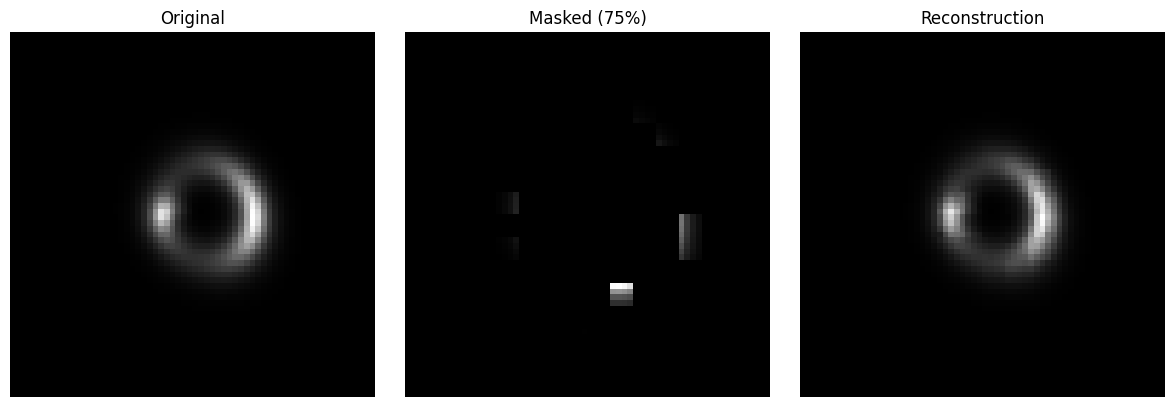

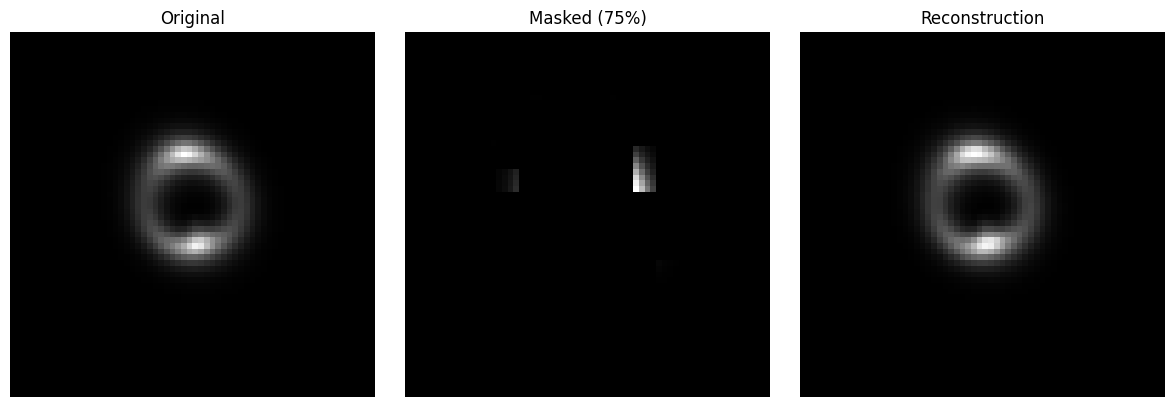

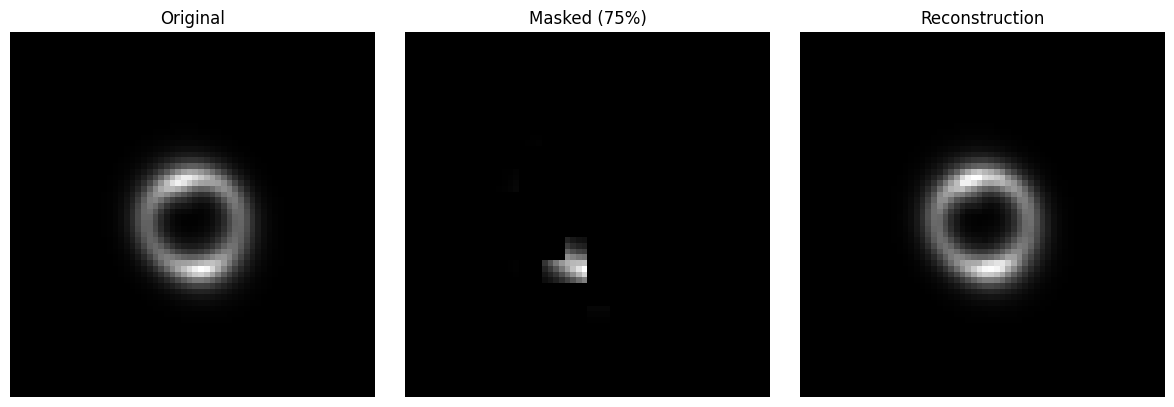

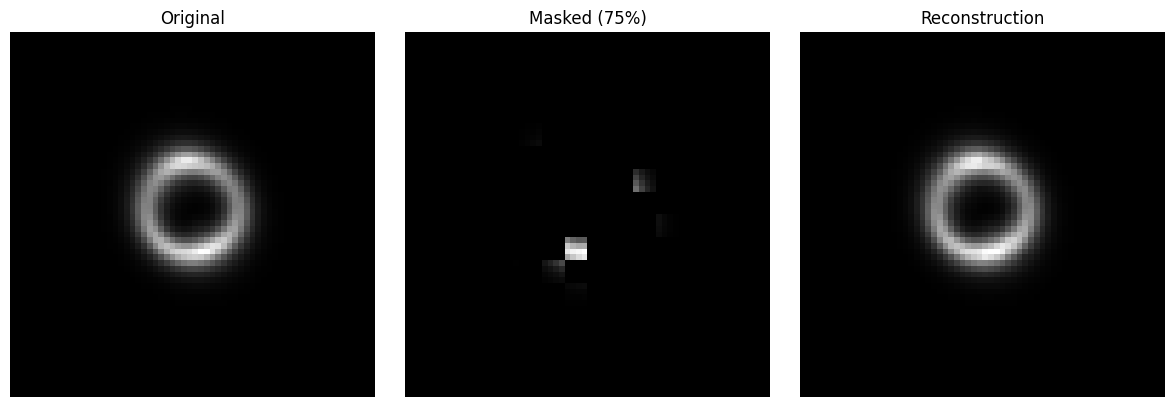

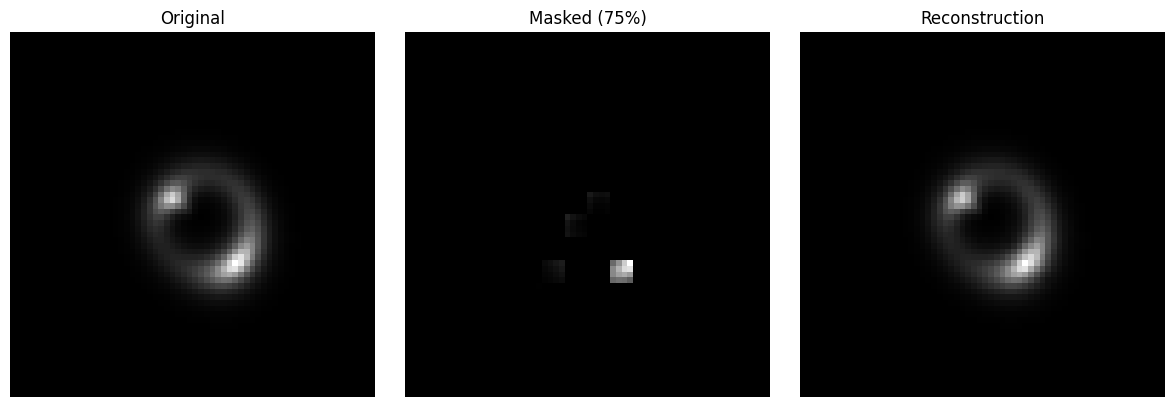

In [11]:
show_mae_reconstruction(mae, mae_loader, device)

In [ ]:
class Classifier(nn.Module):
    
    def __init__(self, encoder, num_classes=3):
        super().__init__()
        self.encoder      = encoder
        dim               = encoder.embed_dim
        self.cls_token    = nn.Parameter(torch.zeros(1, 1, dim))
        self.cls_pos_embed = nn.Parameter(torch.zeros(1, 1, dim))
        self.head         = nn.Linear(dim, num_classes)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.cls_pos_embed, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.encoder.patch_embed(x) + self.encoder.pos_embed  # (B, 256, C)
        cls = self.cls_token.expand(B, -1, -1) + self.cls_pos_embed  # (B, 1, C)
        x   = torch.cat([cls, x], dim=1)                              # (B, 257, C)
        for blk in self.encoder.blocks:
            x = blk(x)
        x = self.encoder.norm(x)

        return self.head(x[:, 0])

In [ ]:
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
import copy


def train_classifier(model, loader, device, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds   = model(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total


def compute_auc(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            probs = torch.softmax(model(imgs.to(device)), dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    return roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro"), all_probs, all_labels

In [ ]:
train_loader = DataLoader(train_split, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_split,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

classifier = Classifier(mae.encoder).to(device)
criterion  = nn.CrossEntropyLoss()

for p in classifier.encoder.parameters():
    p.requires_grad = False

optimizer_s1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, classifier.parameters()),
    lr=1e-3, weight_decay=1e-4
)

print("=== Stage 1: Head warm-up (encoder frozen) ===")
for epoch in range(5):
    loss, acc = train_classifier(classifier, train_loader, device, optimizer_s1, criterion)
    val_acc   = evaluate(classifier, test_loader, device)
    print(f"  Epoch {epoch+1}/5  Loss: {loss:.4f}  Train Acc: {acc:.4f}  Val Acc: {val_acc:.4f}")

for p in classifier.encoder.parameters():
    p.requires_grad = True

FINETUNE_EPOCHS = 15
optimizer_s2    = torch.optim.AdamW(classifier.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler_s2    = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_s2, T_max=FINETUNE_EPOCHS)

best_auc        = 0.0
best_state      = None
patience        = 5
no_improve      = 0

print("\n=== Stage 2: Full fine-tuning (early stopping on val AUC) ===")
for epoch in range(FINETUNE_EPOCHS):
    loss, acc = train_classifier(classifier, train_loader, device, optimizer_s2, criterion)
    auc, _, _ = compute_auc(classifier, test_loader, device)
    val_acc   = evaluate(classifier, test_loader, device)
    scheduler_s2.step()

    improved = auc > best_auc
    if improved:
        best_auc   = auc
        best_state = copy.deepcopy(classifier.state_dict())
        no_improve = 0
    else:
        no_improve += 1

    flag = " ✓ best" if improved else ""
    print(
        f"  Epoch {epoch+1:>2}/{FINETUNE_EPOCHS}  Loss: {loss:.4f}  "
        f"Train Acc: {acc:.4f}  Val Acc: {val_acc:.4f}  AUC: {auc:.4f}{flag}"
    )

    if no_improve >= patience:
        print(f"  Early stopping at epoch {epoch+1} (no AUC improvement for {patience} epochs)")
        break

classifier.load_state_dict(best_state)
print(f"\nRestored best model  |  Best Val AUC: {best_auc:.4f}")

=== Stage 1: Head warm-up (encoder frozen) ===


  Epoch 1/5  Loss: 1.0373  Train Acc: 0.4409  Val Acc: 0.5042


  Epoch 2/5  Loss: 0.9439  Train Acc: 0.5301  Val Acc: 0.5756


  Epoch 3/5  Loss: 0.8887  Train Acc: 0.5733  Val Acc: 0.5482


  Epoch 4/5  Loss: 0.8473  Train Acc: 0.6094  Val Acc: 0.6270


...

  Epoch 11/15  Loss: 0.1402  Train Acc: 0.9420  Val Acc: 0.9486  AUC: 0.9937 ✓ best


  Epoch 12/15  Loss: 0.1228  Train Acc: 0.9501  Val Acc: 0.9529  AUC: 0.9948 ✓ best


  Epoch 13/15  Loss: 0.1099  Train Acc: 0.9556  Val Acc: 0.9542  AUC: 0.9950 ✓ best


  Epoch 14/15  Loss: 0.0998  Train Acc: 0.9601  Val Acc: 0.9590  AUC: 0.9962 ✓ best


  Epoch 15/15  Loss: 0.0929  Train Acc: 0.9633  Val Acc: 0.9614  AUC: 0.9963 ✓ best

Restored best model  |  Best Val AUC: 0.9963


In [ ]:
auc, all_probs, all_labels = compute_auc(classifier, test_loader, device)
print(f"Macro ROC-AUC: {auc:.4f}")

CLASS_NAMES = ["no_sub", "cdm", "axion"]
for i, cls in enumerate(CLASS_NAMES):
    auc_i = roc_auc_score((all_labels == i).astype(int), all_probs[:, i])
    print(f"  AUC {cls}: {auc_i:.4f}")

Macro ROC-AUC: 0.9963
  AUC no_sub: 0.9998
  AUC cdm: 0.9940
  AUC axion: 0.9952


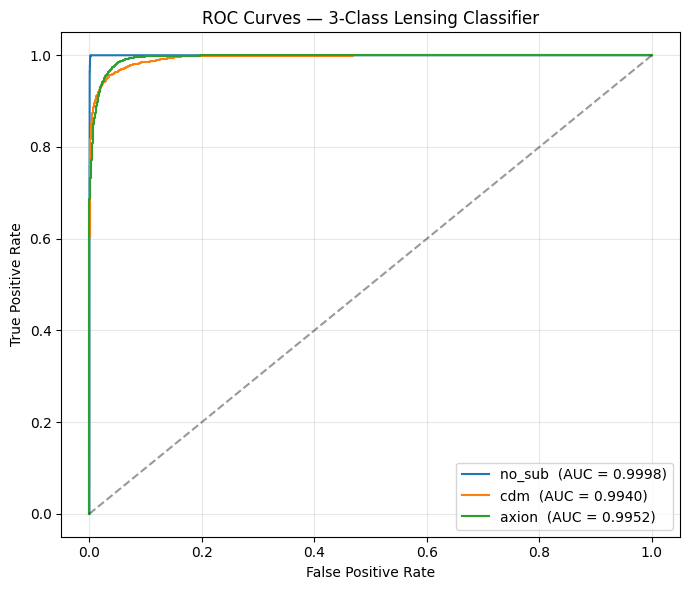

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

CLASS_NAMES = ["no_sub", "cdm", "axion"]
labels_bin  = label_binarize(all_labels, classes=[0, 1, 2])

plt.figure(figsize=(7, 6))
for i, cls in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    auc_i       = roc_auc_score(labels_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f"{cls}  (AUC = {auc_i:.4f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — 3-Class Lensing Classifier")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

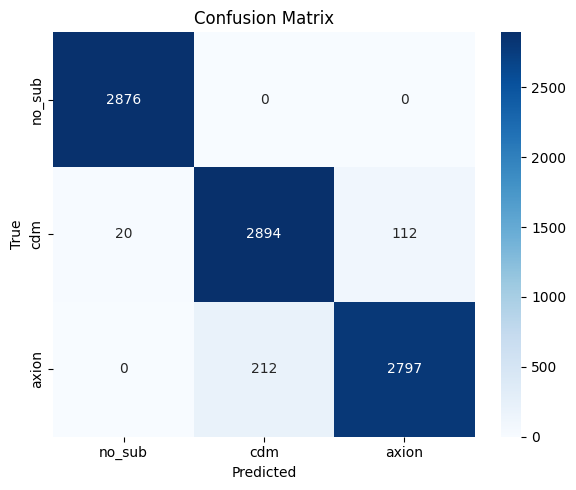


Per-Class Classification Report:
              precision    recall  f1-score   support

      no_sub       0.99      1.00      1.00      2876
         cdm       0.93      0.96      0.94      3026
       axion       0.96      0.93      0.95      3009

    accuracy                           0.96      8911
   macro avg       0.96      0.96      0.96      8911
weighted avg       0.96      0.96      0.96      8911



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

classifier.eval()
all_preds_list = []
with torch.no_grad():
    for imgs, _ in test_loader:
        preds = classifier(imgs.to(device)).argmax(1)
        all_preds_list.extend(preds.cpu().numpy())
all_preds_arr = np.array(all_preds_list)

cm = confusion_matrix(all_labels, all_preds_arr)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax
)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

print("\nPer-Class Classification Report:")
print(classification_report(all_labels, all_preds_arr, target_names=CLASS_NAMES))

**Task IX.B**: Take the pre-trained model from Task IX.A and fine-tune it for a super-resolution task. The model should be fine-tuned to upscale low-resolution strong lensing images using the provided high-resolution samples as ground truths. Please implement your approach in PyTorch or Keras and discuss your strategy.    
**Dataset**: https://drive.google.com/file/d/1uJmDZw649XS-r-dYs9WD-OPwF_TIroVw/view?usp=sharing    
**Dataset Description**: The dataset comprises simulated strong lensing images with no substructure at multiple resolutions: high-resolution (HR) and low-resolution (LR).   
**Evaluation Metrics**: MSE (Mean Squared Error), SSIM (Structural Similarity Index), PSNR (Peak Signal-to-Noise Ratio)


In [ ]:
import os, glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np


class SRDataset(Dataset):

    def __init__(self, hr_dir, lr_dir):
        hr_files = {os.path.basename(f): f for f in glob.glob(os.path.join(hr_dir, "*.npy"))}
        lr_files = {os.path.basename(f): f for f in glob.glob(os.path.join(lr_dir, "*.npy"))}
        common        = sorted(set(hr_files) & set(lr_files))
        self.hr_paths = [hr_files[k] for k in common]
        self.lr_paths = [lr_files[k] for k in common]
        print(f"SRDataset: {len(common)} paired samples")

    @staticmethod
    def _norm(arr):
        mn, mx = arr.min(), arr.max()
        return (arr - mn) / (mx - mn + 1e-8)

    def __len__(self):
        return len(self.hr_paths)

    def __getitem__(self, idx):
        hr = torch.from_numpy(self._norm(np.load(self.hr_paths[idx]).astype(np.float32)))
        lr = torch.from_numpy(self._norm(np.load(self.lr_paths[idx]).astype(np.float32)))
        lr = F.interpolate(
            lr.unsqueeze(0), size=(64, 64), mode="bilinear", align_corners=False
        ).squeeze(0)
        return lr, hr


sr_base    = "/kaggle/input/datasets/anukultiwari/sr-dataset/SR_Dataset"
sr_dataset = SRDataset(os.path.join(sr_base, "HR"), os.path.join(sr_base, "LR"))

n_train = int(0.8 * len(sr_dataset))
n_val   = len(sr_dataset) - n_train
sr_train_ds, sr_val_ds = random_split(
    sr_dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42)
)
sr_train_loader = DataLoader(sr_train_ds, batch_size=32, shuffle=True,  num_workers=0)
sr_val_loader   = DataLoader(sr_val_ds,   batch_size=32, shuffle=False, num_workers=0)
print(f"SR Train: {n_train}, Val: {n_val}")

SRDataset: 10000 paired samples
SR Train: 8000, Val: 2000


In [ ]:
class SRDecoder(nn.Module):

    def __init__(self, embed_dim=192, hr_size=150):
        super().__init__()
        self.hr_size = hr_size
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(embed_dim, 128, kernel_size=4, stride=2, padding=1),  # 16→32
            nn.BatchNorm2d(128), nn.GELU()
        )
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),          # 32→64
            nn.BatchNorm2d(64), nn.GELU()
        )
        self.up3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),           # 64→128
            nn.BatchNorm2d(32), nn.GELU()
        )
        self.head = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1), nn.GELU(),
            nn.Conv2d(16,  1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        B = x.shape[0]
        x = x.reshape(B, 16, 16, -1).permute(0, 3, 1, 2)              # (B, 192, 16, 16)
        x = self.up1(x)                                               # (B, 128, 32, 32)
        x = self.up2(x)                                               # (B,  64, 64, 64)
        x = self.up3(x)                                               # (B,  32,128,128)
        x = self.head(x)                                              # (B,   1,128,128)
        return F.interpolate(x, size=(self.hr_size, self.hr_size),
                            mode="bilinear", align_corners=False)    # (B,   1,150,150)


class ViTSuperRes(nn.Module):

    def __init__(self, encoder, embed_dim=192, hr_size=150):
        super().__init__()
        self.encoder = encoder
        self.decoder = SRDecoder(embed_dim, hr_size)

    def forward(self, lr):
        return self.decoder(self.encoder(lr))


sr_model = ViTSuperRes(mae.encoder).to(device)

# Initially freeze encoder
for p in sr_model.encoder.parameters():
    p.requires_grad = False

total     = sum(p.numel() for p in sr_model.parameters())
trainable = sum(p.numel() for p in sr_model.parameters() if p.requires_grad)
print(f"SR model: {total:,} total params, {trainable:,} trainable (decoder only)")

SR model: 3,284,481 total params, 562,497 trainable (decoder only)


In [ ]:
def train_sr(model, train_loader, val_loader, device,
            phase1_epochs=10, phase2_epochs=10,
            lr_phase1=1e-3, lr_phase2=1e-4):
    criterion = nn.MSELoss()
    history   = {"train_loss": [], "val_loss": [], "phase": []}

    def _run_epoch(model, loader, optimizer=None, train=True):
        model.train() if train else model.eval()
        total, n = 0.0, 0
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for lr_imgs, hr_imgs in loader:
                lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
                sr   = model(lr_imgs)
                loss = criterion(sr, hr_imgs)
                if train:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                total += loss.item() * lr_imgs.size(0)
                n     += lr_imgs.size(0)
        return total / n

    opt1  = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr_phase1, weight_decay=1e-4
    )
    sch1  = torch.optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=phase1_epochs)

    print("Phase 1: Training SR decoder (encoder frozen)")
    for epoch in range(1, phase1_epochs + 1):
        tr = _run_epoch(model, train_loader, opt1,  train=True)
        vl = _run_epoch(model, val_loader,   train=False)
        sch1.step()
        history["train_loss"].append(tr)
        history["val_loss"].append(vl)
        history["phase"].append(1)
        print(f"  Epoch {epoch:>2}/{phase1_epochs}  Train MSE: {tr:.6f}  Val MSE: {vl:.6f}")

    for p in model.encoder.parameters():
        p.requires_grad = True
    opt2 = torch.optim.AdamW(model.parameters(), lr=lr_phase2, weight_decay=1e-4)
    sch2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=phase2_epochs)

    print("\nPhase 2: Fine-tuning encoder + decoder")
    for epoch in range(1, phase2_epochs + 1):
        tr = _run_epoch(model, train_loader, opt2,  train=True)
        vl = _run_epoch(model, val_loader,   train=False)
        sch2.step()
        history["train_loss"].append(tr)
        history["val_loss"].append(vl)
        history["phase"].append(2)
        print(f"  Epoch {epoch:>2}/{phase2_epochs}  Train MSE: {tr:.6f}  Val MSE: {vl:.6f}")

    return history


sr_history = train_sr(sr_model, sr_train_loader, sr_val_loader, device,
                    phase1_epochs=10, phase2_epochs=10)

Phase 1: Training SR decoder (encoder frozen)
  Epoch  1/10  Train MSE: 0.000801  Val MSE: 0.000194
  Epoch  2/10  Train MSE: 0.000199  Val MSE: 0.000159
  Epoch  3/10  Train MSE: 0.000162  Val MSE: 0.000200
  Epoch  4/10  Train MSE: 0.000148  Val MSE: 0.000137
  Epoch  5/10  Train MSE: 0.000133  Val MSE: 0.000123
  Epoch  6/10  Train MSE: 0.000126  Val MSE: 0.000112
  Epoch  7/10  Train MSE: 0.000122  Val MSE: 0.000139
  Epoch  8/10  Train MSE: 0.000112  Val MSE: 0.000102
  Epoch  9/10  Train MSE: 0.000107  Val MSE: 0.000099
  Epoch 10/10  Train MSE: 0.000108  Val MSE: 0.000100

Phase 2: Fine-tuning encoder + decoder
  Epoch  1/10  Train MSE: 0.000114  Val MSE: 0.000124
  Epoch  2/10  Train MSE: 0.000115  Val MSE: 0.000129
  Epoch  3/10  Train MSE: 0.000108  Val MSE: 0.000110
  Epoch  4/10  Train MSE: 0.000105  Val MSE: 0.000130
  Epoch  5/10  Train MSE: 0.000102  Val MSE: 0.000097
  Epoch  6/10  Train MSE: 0.000104  Val MSE: 0.000092
  Epoch  7/10  Train MSE: 0.000099  Val MSE: 0.000

In [ ]:
import math


def compute_psnr(mse, max_val=1.0):
    return float("inf") if mse == 0 else 10.0 * math.log10(max_val ** 2 / mse)


def compute_ssim(img1, img2, C1=1e-4, C2=9e-4):
    mu1, mu2  = F.avg_pool2d(img1, 11, 1, 5), F.avg_pool2d(img2, 11, 1, 5)
    s1        = F.avg_pool2d(img1 * img1, 11, 1, 5) - mu1 * mu1
    s2        = F.avg_pool2d(img2 * img2, 11, 1, 5) - mu2 * mu2
    s12       = F.avg_pool2d(img1 * img2, 11, 1, 5) - mu1 * mu2
    num       = (2 * mu1 * mu2 + C1) * (2 * s12 + C2)
    den       = (mu1 ** 2 + mu2 ** 2 + C1) * (s1 + s2 + C2)
    return (num / den).mean().item()


@torch.no_grad()
def evaluate_sr(model, loader, device):
    model.eval()
    total_mse, total_ssim, n = 0.0, 0.0, 0
    for lr_imgs, hr_imgs in loader:
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
        sr  = model(lr_imgs).clamp(0, 1)
        b   = lr_imgs.size(0)
        total_mse  += F.mse_loss(sr, hr_imgs, reduction="sum").item()
        total_ssim += compute_ssim(sr, hr_imgs) * b
        n  += b
    mse  = total_mse / (n * 1 * 150 * 150)
    ssim = total_ssim / n
    return mse, ssim, compute_psnr(mse)


@torch.no_grad()
def evaluate_bicubic(loader, device):
    total_mse, total_ssim, n = 0.0, 0.0, 0
    for lr_imgs, hr_imgs in loader:
        hr_imgs = hr_imgs.to(device)
        bicubic = F.interpolate(
            lr_imgs.to(device), size=(150, 150), mode="bicubic", align_corners=False
        ).clamp(0, 1)
        b = lr_imgs.size(0)
        total_mse  += F.mse_loss(bicubic, hr_imgs, reduction="sum").item()
        total_ssim += compute_ssim(bicubic, hr_imgs) * b
        n += b
    mse  = total_mse / (n * 1 * 150 * 150)
    ssim = total_ssim / n
    return mse, ssim, compute_psnr(mse)


mse_model,   ssim_model,   psnr_model   = evaluate_sr(sr_model, sr_val_loader, device)
mse_bicubic, ssim_bicubic, psnr_bicubic = evaluate_bicubic(sr_val_loader, device)

print("                  MSE        SSIM    PSNR (dB)")
print(f"Bicubic baseline  {mse_bicubic:.6f}   {ssim_bicubic:.4f}   {psnr_bicubic:.2f}")
print(f"ViT-SR model      {mse_model:.6f}   {ssim_model:.4f}   {psnr_model:.2f}")
print(f"\nImprovement       ΔMSE: {mse_bicubic - mse_model:.6f}  "
    f"ΔSSIM: {ssim_model - ssim_bicubic:.4f}  "
    f"ΔPSNR: {psnr_model - psnr_bicubic:.2f} dB")

                  MSE        SSIM    PSNR (dB)
Bicubic baseline  0.000100   0.9689   40.01
ViT-SR model      0.000089   0.9758   40.49

Improvement       ΔMSE: 0.000010  ΔSSIM: 0.0069  ΔPSNR: 0.48 dB


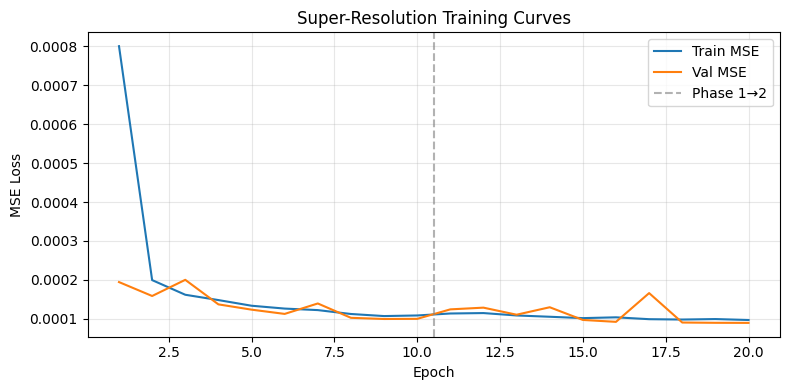

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
epochs   = range(1, len(sr_history["train_loss"]) + 1)
phase1_end = sum(1 for p in sr_history["phase"] if p == 1)
ax.plot(epochs, sr_history["train_loss"], label="Train MSE")
ax.plot(epochs, sr_history["val_loss"],   label="Val MSE")
ax.axvline(phase1_end + 0.5, color="gray", linestyle="--", alpha=0.6, label="Phase 1→2")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("Super-Resolution Training Curves")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

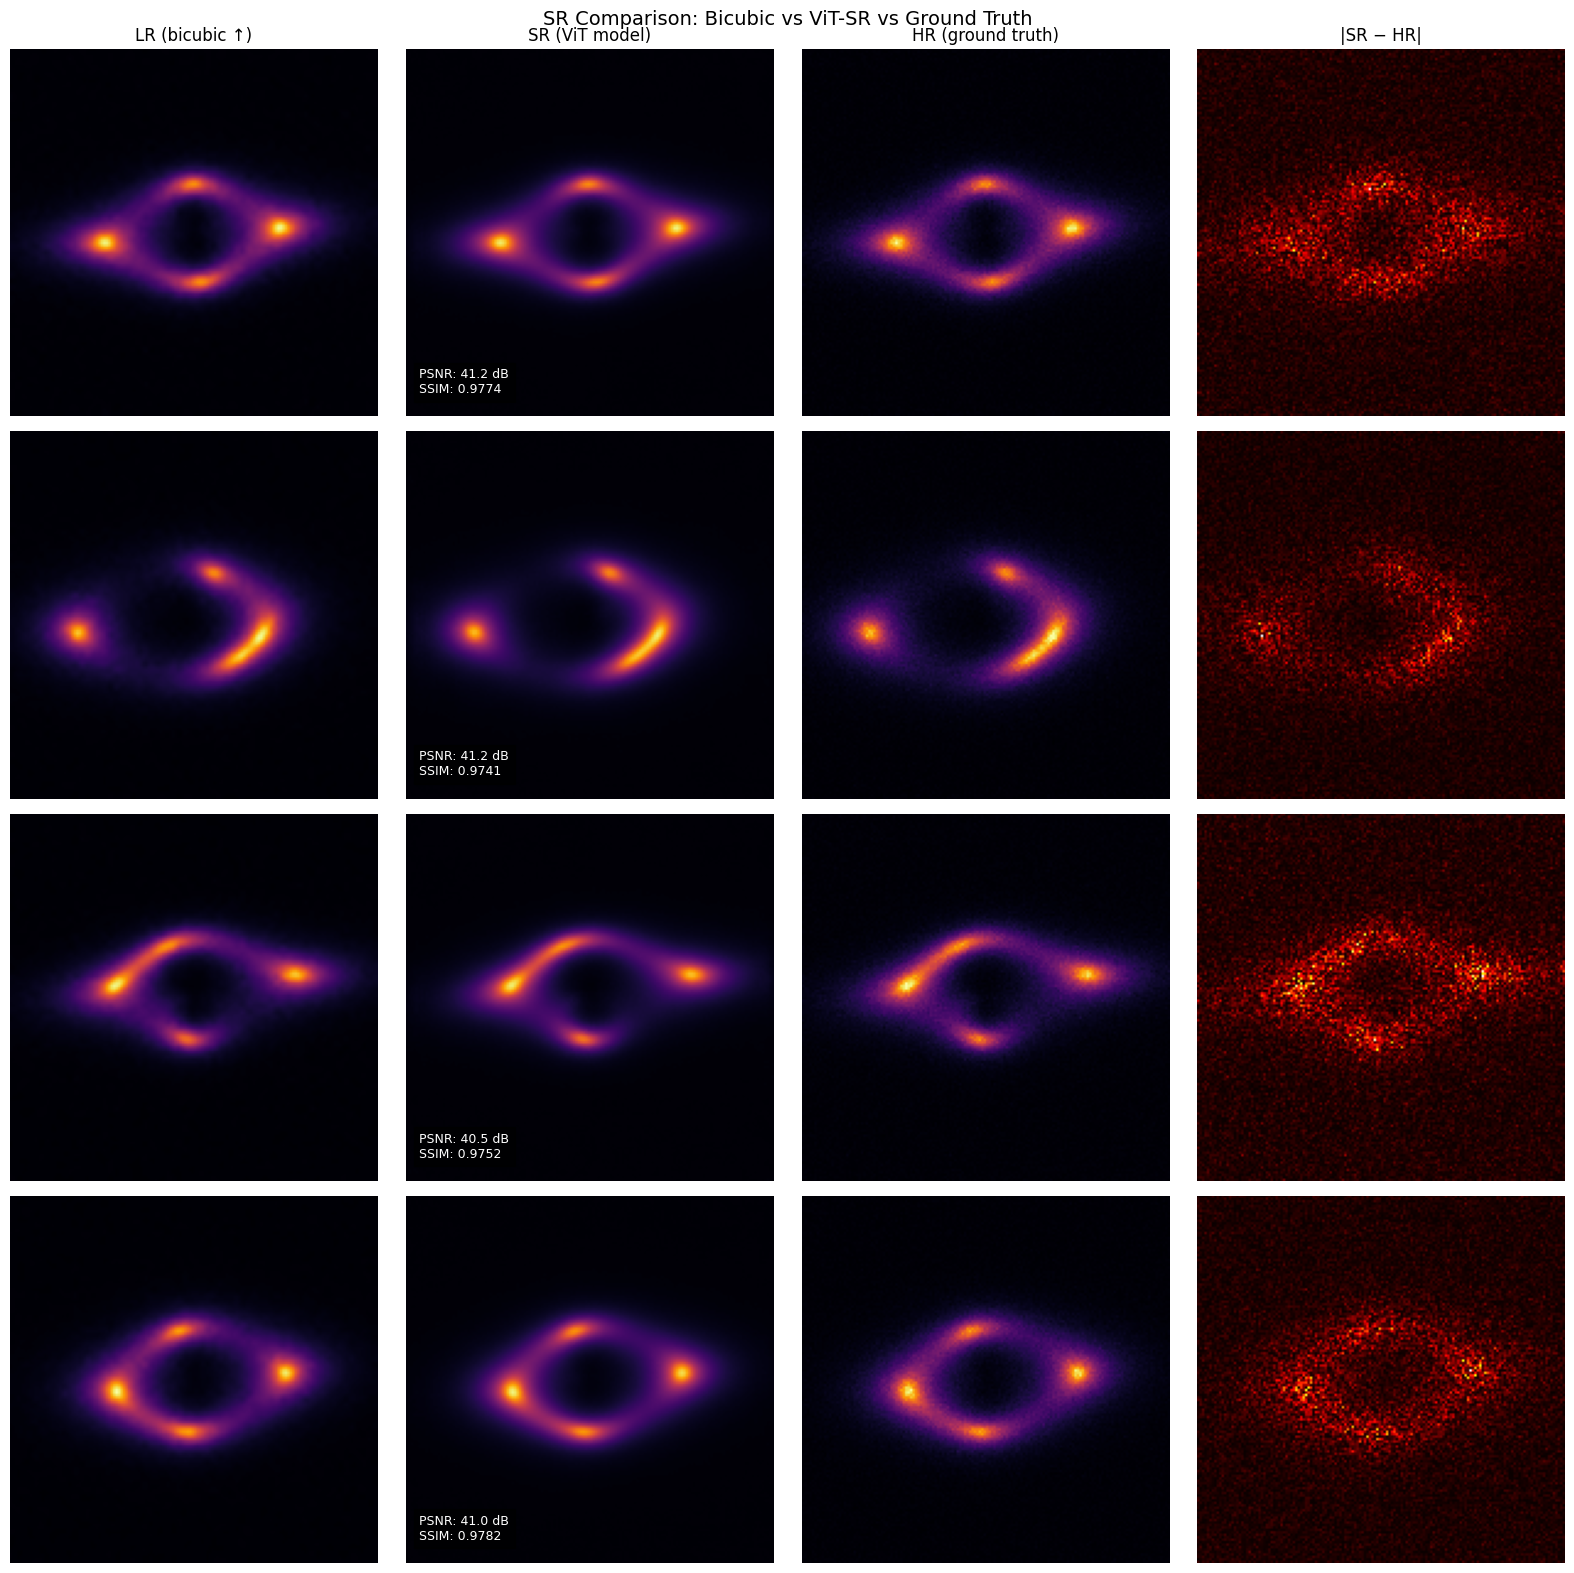

In [ ]:
sr_model.eval()
vis_loader         = DataLoader(sr_val_ds, batch_size=4, shuffle=True)
lr_batch, hr_batch = next(iter(vis_loader))

with torch.no_grad():
    sr_batch    = sr_model(lr_batch.to(device)).clamp(0, 1).cpu()
    bicubic_batch = F.interpolate(
        lr_batch, size=(150, 150), mode="bicubic", align_corners=False
    ).clamp(0, 1)

n_show = 4
fig, axes = plt.subplots(n_show, 4, figsize=(16, 4 * n_show))
col_titles = ["LR (bicubic ↑)", "SR (ViT model)", "HR (ground truth)", "|SR − HR|"]

for i in range(n_show):
    hr_img  = hr_batch[i, 0]
    sr_img  = sr_batch[i, 0]
    bic_img = bicubic_batch[i, 0]
    diff    = (sr_img - hr_img).abs()

    img_mse  = F.mse_loss(sr_img, hr_img).item()
    img_psnr = compute_psnr(img_mse)
    img_ssim = compute_ssim(sr_batch[i:i+1], hr_batch[i:i+1])

    for j, (img, cmap) in enumerate([
        (bic_img, "inferno"), (sr_img, "inferno"), (hr_img, "inferno"), (diff, "hot")
    ]):
        axes[i, j].imshow(img.numpy(), cmap=cmap, vmin=0, vmax=1 if j < 3 else diff.max())
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(col_titles[j], fontsize=12)

    axes[i, 1].text(
        5, 140, f"PSNR: {img_psnr:.1f} dB\nSSIM: {img_ssim:.4f}",
        color="white", fontsize=9, bbox=dict(facecolor="black", alpha=0.6)
    )

plt.suptitle("SR Comparison: Bicubic vs ViT-SR vs Ground Truth", fontsize=14)
plt.tight_layout()
plt.show()